# Hotel Booking Cancellation: Explanatory vs. Predictive Classification

## Objective:

Implement and compare two classification models — one explanatory and one predictive — following technical rigor and best practices in Data Mining and Predictive Modeling.

### Sub-objectives:
- Differentiate and contrast the explanatory approach versus the predictive approach in classification problems.
- Identify and extract the key patterns in the features that determine the behavior of the target variable.
- Optimize predictive performance through feature transformations.
- Develop clean, well-structured code with efficient error handling to keep the data pipeline robust.
- Independently use the _scikit-learn_ and _statsmodels_ documentation to implement algorithms and resolve technical questions.

## Approach:

This project is limited to the _pandas_, _numpy_, _scikit-learn_, and _statsmodels_ libraries, with close attention paid to avoiding data leakage throughout the pipeline.


# Part 0: Libraries

In [1]:
# Space reserved for library imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PowerTransformer, StandardScaler
import statsmodels.api as sm
pd.set_option('display.max_columns', None)

seed = 99

# Additional libraries can be added here as needed


# Part 0: Dataset

This project uses the following "Hotel booking cancellation" dataset. Each record represents a booking that was either cancelled or fulfilled by a customer. More detail on the columns follows below:

**target**:
- *reserva_cancelada*: Indicates whether the booking was cancelled (1) or not cancelled (0).

**features**:
- *dias_antelacion*: Number of days between the date the customer made the booking and the date of arrival at the hotel.
- *fecha_llegada*: Start date of the booking.
- *noches_estancia*: Total nights of the stay.
- *estado_reserva*: Final status of the booking. Values: Canceled (the customer cancelled), Check-Out (the customer completed the stay), No-Show (the customer never showed up nor cancelled).
- *fecha_estado_reserva*: Date the estado_reserva value was recorded.
- *adultos*: Number of adults included in the booking.
- *ninos*: Number of children.
- *bebes*: Number of babies.
- *regimen_alimenticio*: Meal plan booked (BB: Breakfast only, HB: Half board, FB: Full board, SC/Undefined: No meals).
- *tipo_habitacion_reservada*: Room type originally requested by the customer (coded by letter: A, B, C...).
- *tipo_habitacion_asignada*: Room type ultimately assigned by the hotel at check-in.
- *plazas_parking_requeridas*: Number of parking spaces requested by the customer.
- *peticiones_especiales_totales*: Number of special requests made (e.g. crib, extra bed, high floor).
- *pais_origen*: Customer's country of origin (three-letter international code, e.g. PRT, ESP, FRA).
- *segmento_mercado*: Market segment the booking belongs to (e.g. Direct, Groups, Corporate travel agencies, etc.).
- *canal_distribucion*: Channel through which the booking reached the hotel (e.g. TA/TO: Travel Agents/Operators, Direct, GDS, etc.).
- *cliente_repetido*: Binary variable (0 or 1). Indicates whether the customer has previously stayed at this hotel.
- *cancelaciones_previas*: Number of bookings this customer has cancelled in the past, prior to the current booking.
- *reservas_previas_no_canceladas*: Number of prior bookings the customer completed successfully (did not cancel).
- *tipo_deposito*: Indicates whether the customer made a deposit to secure the booking (No Deposit, Non Refundable, Refundable).
- *cambios_reserva*: Number of modifications or changes made to the booking from creation until arrival.
- *dias_lista_espera*: Number of days the booking was held on a waiting list before being confirmed.
- *tipo_cliente*: Type of customer/booking (Transient: Individual, Group: Group, Contract: Recurring corporate rate, Transient-Party: Individual linked to a group).
- *precio_medio_diario*: Average Daily Rate paid by the customer per room night.


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/reservas_hotel.csv")
df.head()

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,fecha_estado_reserva,fecha_llegada,noches_estancia
0,0,342,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-06,0
1,0,737,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-06,0
2,0,7,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-06,1
3,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-06,1
4,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-06,2


In [3]:
df.shape

(119390, 25)

In [4]:
# All the work will be carried out using df1.
# We'll keep the variable df around to compare against when necessary.

df1 = df.copy()

# Part 1: Dataset Preprocessing (EDA + Feature Engineering)

## Date variables

This section identifies the date variables and creates new features that may be useful for finding cancellation "patterns".

Only the date columns are used here. At the end of each cell, the original date column is dropped, with a comment for each **new feature** created explaining what it means.

<div class="alert alert-block alert-danger">
<b>Important:</b> Special attention is paid to "data leakage" — using "future" information or data that wouldn't be available in the real world can completely invalidate a predictive or explanatory model.
</div>

In [5]:
df1['fecha_estado_reserva'] = pd.to_datetime(df1['fecha_estado_reserva'], format='%Y-%m-%d')
df1['fecha_llegada'] = pd.to_datetime(df1['fecha_llegada'], format='%Y-%m-%d')

df1['dia_mes_llegada'] = df1['fecha_llegada'].dt.day.astype('int64')
df1['mes_llegada'] = df1['fecha_llegada'].dt.month.astype('int64')
df1['anio_llegada'] = df1['fecha_llegada'].dt.year.astype('int64')
df1['dia_semana_llegada'] = df1['fecha_llegada'].dt.weekday.astype('int64')
df1['es_fin_de_semana'] = df1['dia_semana_llegada'].apply(lambda x: 1 if x >= 5 else 0)

# Drop the original date columns
df1.drop(columns=['fecha_estado_reserva', 'fecha_llegada'], inplace=True)

In [6]:
df1.head()

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,noches_estancia,dia_mes_llegada,mes_llegada,anio_llegada,dia_semana_llegada,es_fin_de_semana
0,0,342,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,0,6,7,2015,0,0
1,0,737,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,0,6,7,2015,0,0
2,0,7,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,1,6,7,2015,0,0
3,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,1,6,7,2015,0,0
4,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2,6,7,2015,0,0


In [7]:
# Explanation of the new columns created
# dia_mes_llegada: Day of the month of arrival
# mes_llegada: Month of arrival
# anio_llegada: Year of arrival
# dia_semana_llegada: Day of the week of arrival
# es_fin_de_semana: Weekend indicator (1 if weekend, 0 otherwise)

## Data split

The original dataset is split into train/test sets, with 20% of the data held out for testing (using a fixed random seed for reproducibility).

<div class="alert alert-block alert-danger">
<b>Important:</b> Special attention is paid to "data leakage" — using test-set information to fit the model, or calling _.fit()_ on the test set, is a serious error when analyzing data and fitting models.
</div>

In [8]:
# The estado_reserva column is also dropped since it's redundant with reserva_cancelada and would cause data leakage.
X = df1.drop(columns=['reserva_cancelada', 'estado_reserva'])
y = df1['reserva_cancelada']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

## Handling missing values

Missing values need to be resolved before moving forward. This section detects the null values in the dataset and decides on an appropriate treatment for each one.

In [9]:
X_train.isna().sum().sort_values(ascending=False).head(5)

pais_origen        370
ninos                1
adultos              0
dias_antelacion      0
bebes                0
dtype: int64

In [10]:
print(f"Percentage of missing values: {df1['pais_origen'].isnull().sum() / df1.shape[0]:.2%}")

¨Porcentaje de datos nulos: 0.41%


In [11]:
print(f"X_train rows before dropping nulls: {X_train.shape[0]}")
print(f"y_train rows before dropping nulls: {y_train.shape[0]}")
print(f"X_test rows before dropping nulls: {X_test.shape[0]}")
print(f"y_test rows before dropping nulls: {y_test.shape[0]}")

Filas de X_train antes de eliminar nulos: 95512
Filas de y_train antes de eliminar nulos: 95512
Filas de X_test antes de eliminar nulos: 23878
Filas de y_test antes de eliminar nulos: 23878


In [12]:
# Drop rows with nulls in 'pais_origen' from the training set
X_train = X_train.dropna(subset=['pais_origen'])
y_train = y_train[X_train.index]

# Drop rows with nulls in 'pais_origen' from the test set
X_test = X_test.dropna(subset=['pais_origen'])
y_test = y_test[X_test.index]

print(f"X_train rows after dropping nulls: {X_train.shape[0]}")
print(f"y_train rows after dropping nulls: {y_train.shape[0]}")
print(f"X_test rows after dropping nulls: {X_test.shape[0]}")
print(f"y_test rows after dropping nulls: {y_test.shape[0]}")

Filas de X_train después de eliminar nulos: 95142
Filas de y_train después de eliminar nulos: 95142
Filas de X_test después de eliminar nulos: 23760
Filas de y_test después de eliminar nulos: 23760


In [13]:
df1[df1['ninos'].isna()]

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,noches_estancia,dia_mes_llegada,mes_llegada,anio_llegada,dia_semana_llegada,es_fin_de_semana
40600,1,2,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,0,Transient-Party,12.0,0,1,Canceled,1,10,8,2015,0,0
40667,1,1,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,0,Transient-Party,12.0,0,1,Canceled,2,10,8,2015,0,0
40679,1,1,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,0,Transient-Party,18.0,0,2,Canceled,2,10,8,2015,0,0
41160,1,8,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,0,Transient-Party,76.5,0,1,Canceled,7,17,8,2015,0,0


In [14]:
df1['ninos'].value_counts()

ninos
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

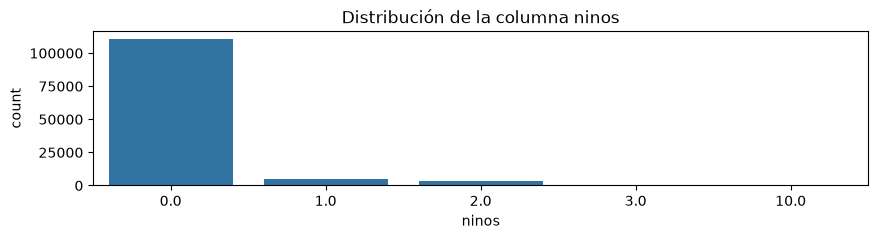

In [15]:
plt.figure(figsize=(10, 2))
sns.countplot(x='ninos', data=df1)
plt.title('Distribution of the ninos column')
plt.show()

In [16]:
# Fill null values in the 'ninos' column with 0 in the training set
X_train['ninos'] = X_train['ninos'].fillna(0)

# Fill null values in the 'ninos' column with 0 in the test set
X_test['ninos'] = X_test['ninos'].fillna(0)


In [17]:
X_train.isna().sum().sort_values(ascending=False).head(5)

dias_antelacion        0
adultos                0
ninos                  0
bebes                  0
regimen_alimenticio    0
dtype: int64

In [18]:
# Explanation of the imputations performed
# pais_origen nulls: rows with null values in the 'pais_origen' column were dropped from both the training and test sets.
# This decision was made because nulls represent only 0.5% of the whole dataset and are not expected to affect the model.

# ninos nulls: null values in the 'ninos' column were filled with 0 in both sets, assuming that missing information about children
# means there are no children in the booking. This imputation is reasonable given that most bookings don't include children.


## Feature exploration and creation of new features

This section explores all the features visually with plots.

In [19]:
X_train.head()

,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,noches_estancia,dia_mes_llegada,mes_llegada,anio_llegada,dia_semana_llegada,es_fin_de_semana
34563,226,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient-Party,30.24,0,0,4,20,3,2017,0,0
117791,0,1,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,B,0,No Deposit,0,Transient,140.00,0,0,1,7,8,2017,0,0
44311,89,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,0,Transient,62.00,0,0,4,5,10,2015,0,0
22365,6,2,0.0,0,BB,FRA,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,46.00,0,0,3,28,3,2016,0,0
82068,22,1,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient-Party,65.00,0,0,1,21,12,2015,0,0


In [20]:
# Split columns by type

cat_cols = X_train.select_dtypes(include=['str']).columns.tolist()
ord_cols = ...
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

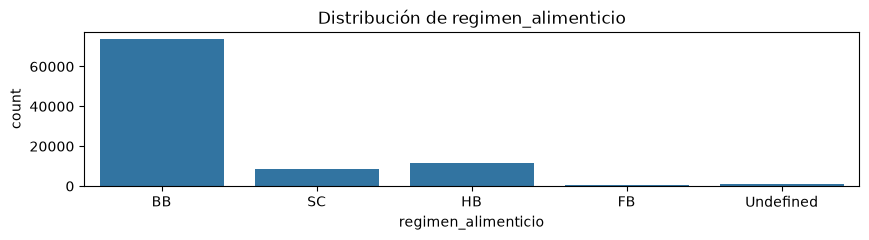

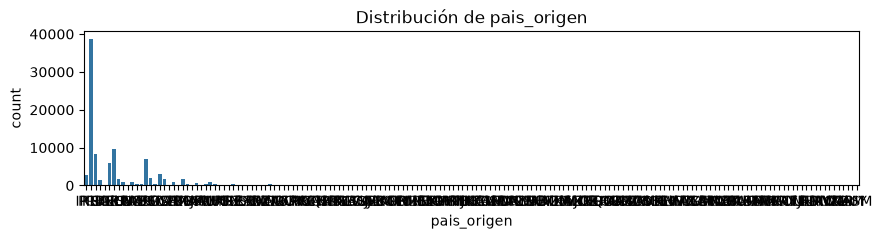

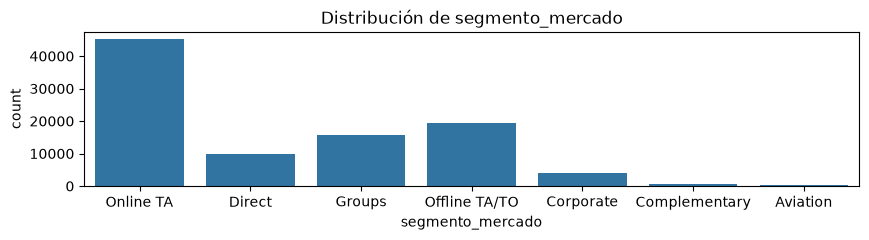

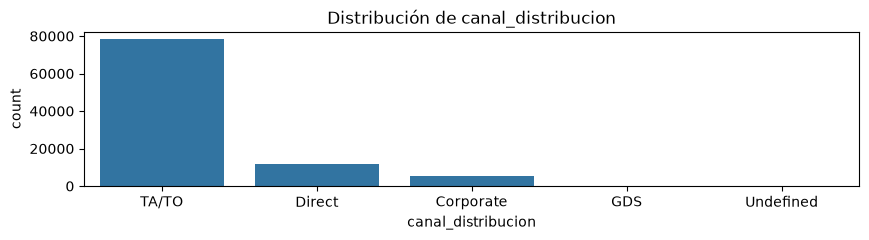

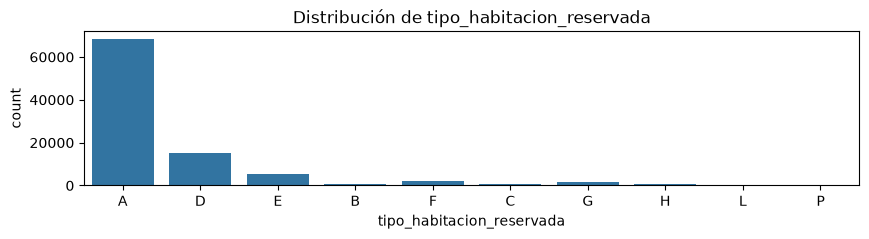

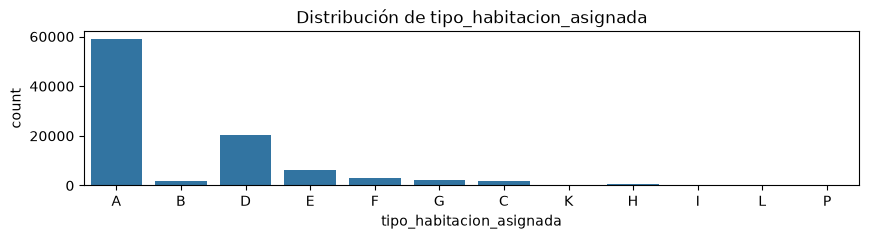

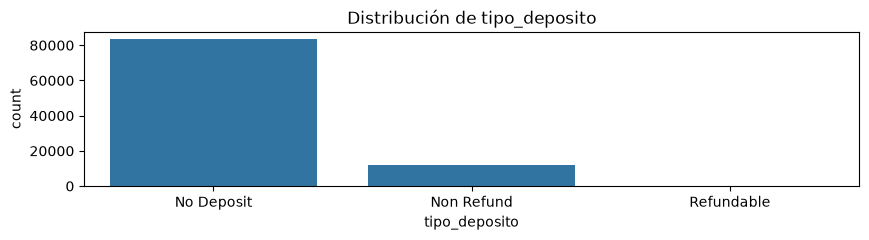

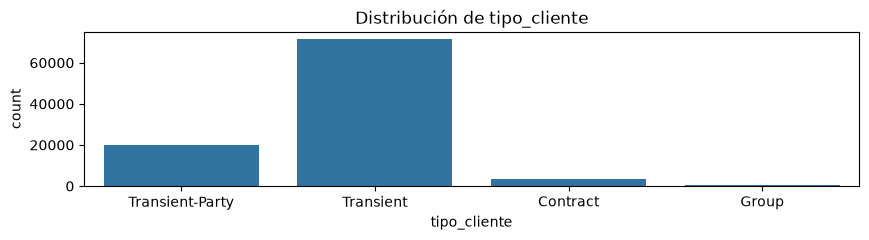

In [21]:
for col in cat_cols:
    plt.figure(figsize=(10, 2))
    sns.countplot(x=col, data=X_train)
    plt.title(f'Distribution of {col}')
    plt.show()


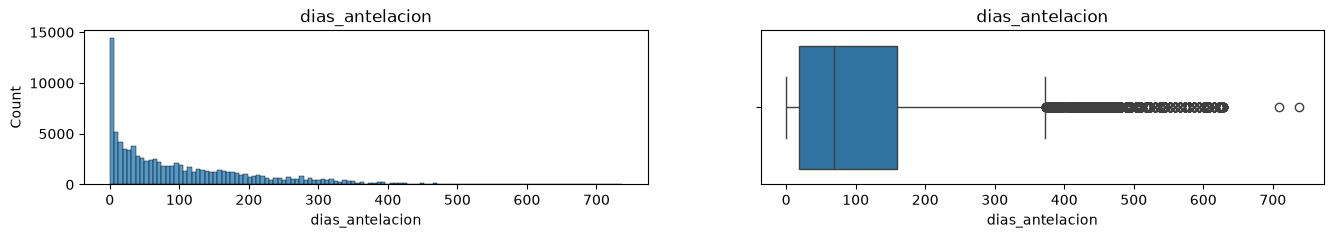

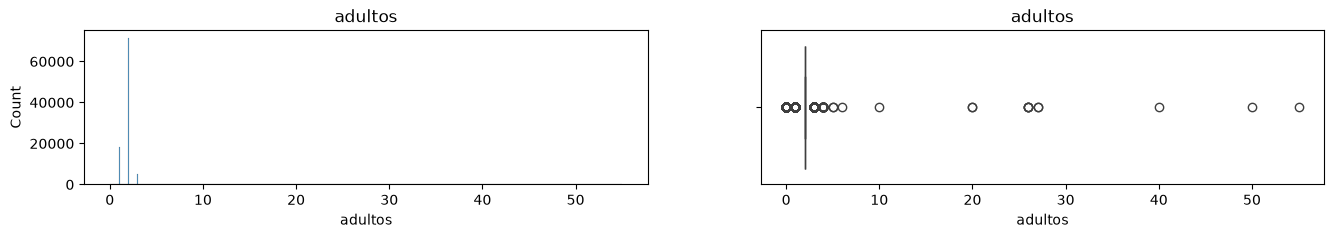

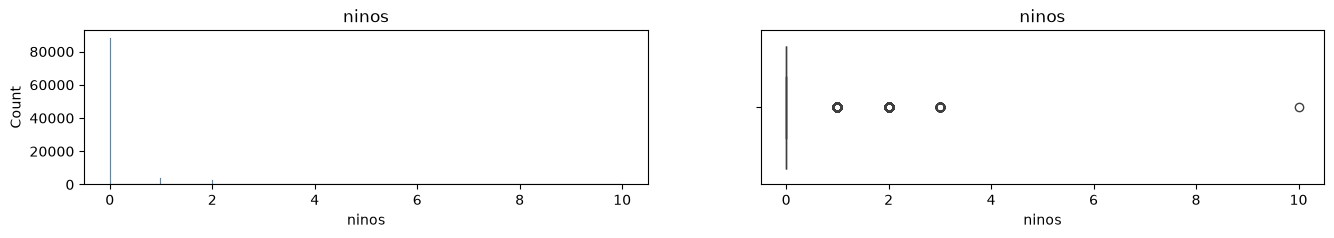

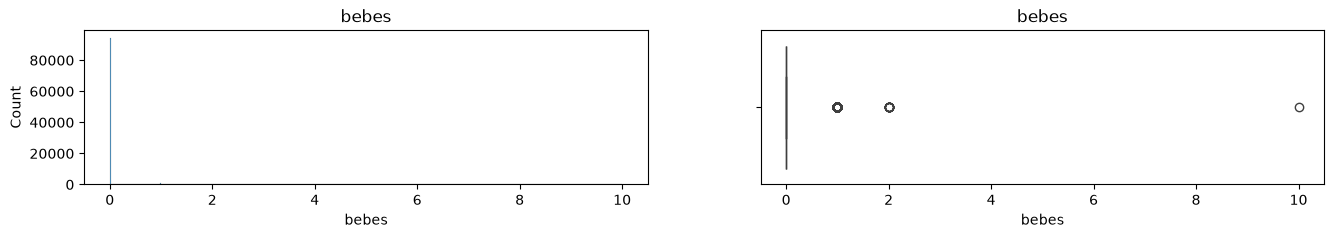

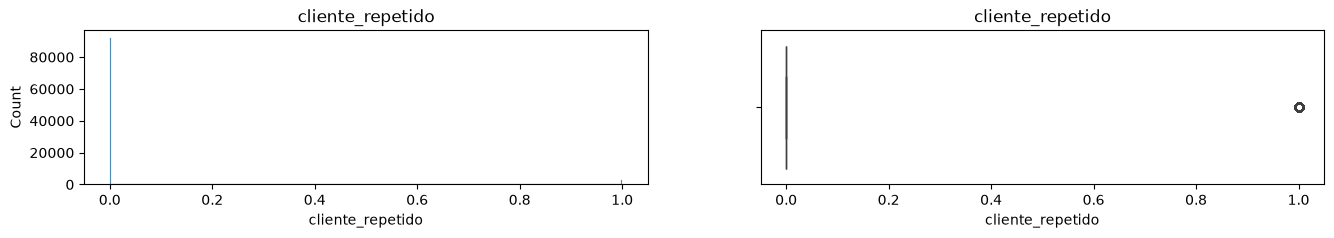

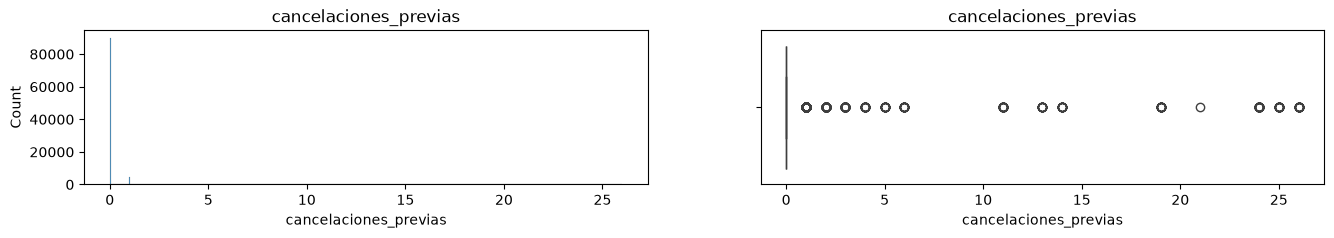

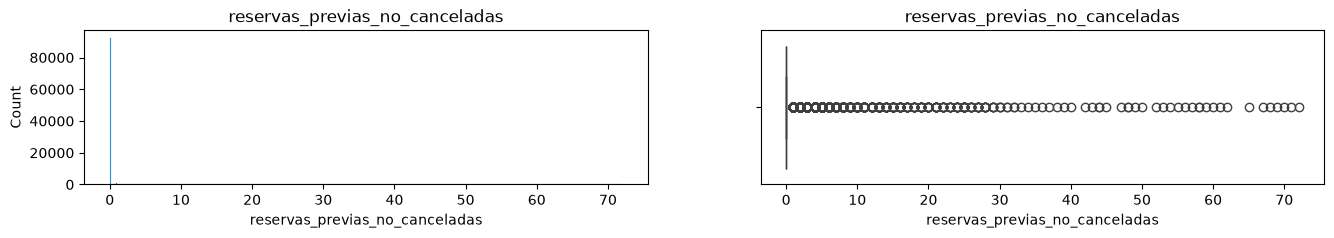

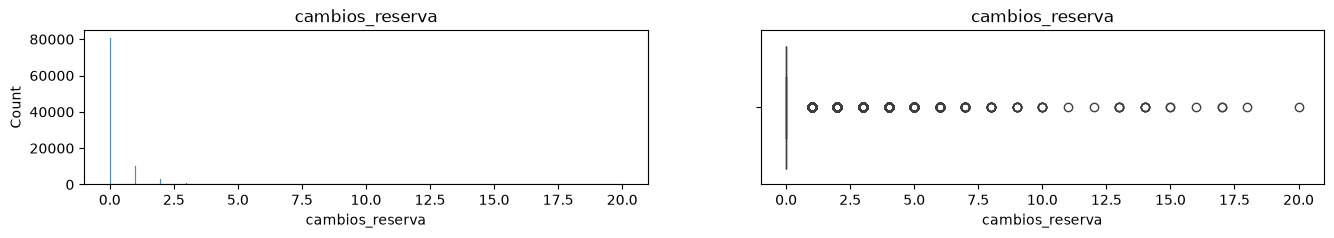

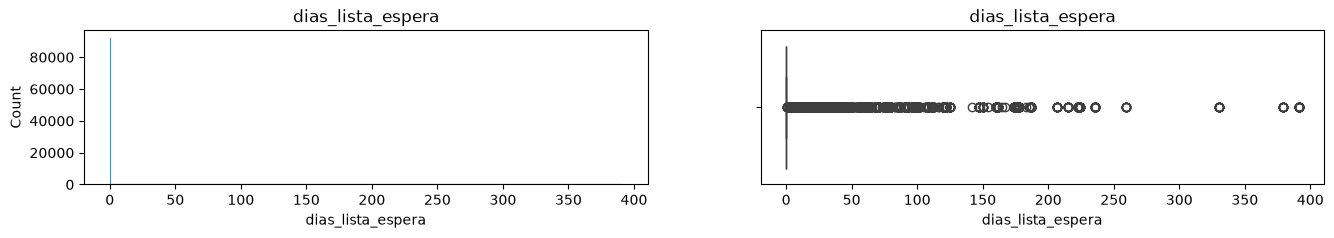

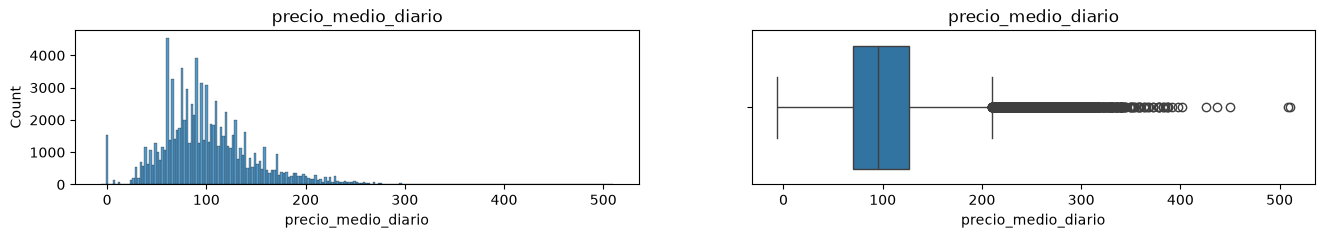

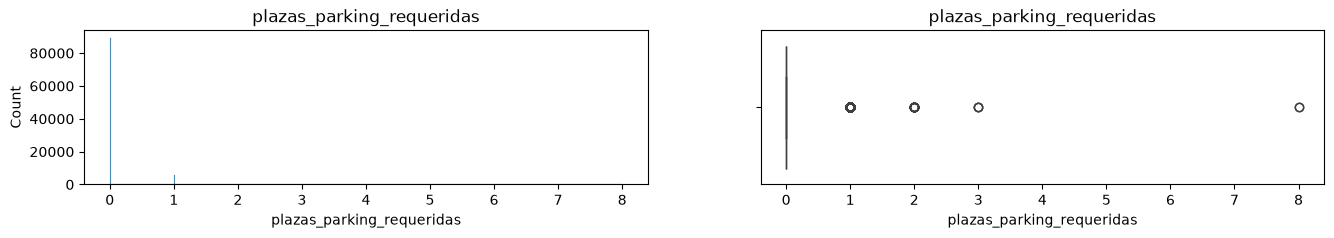

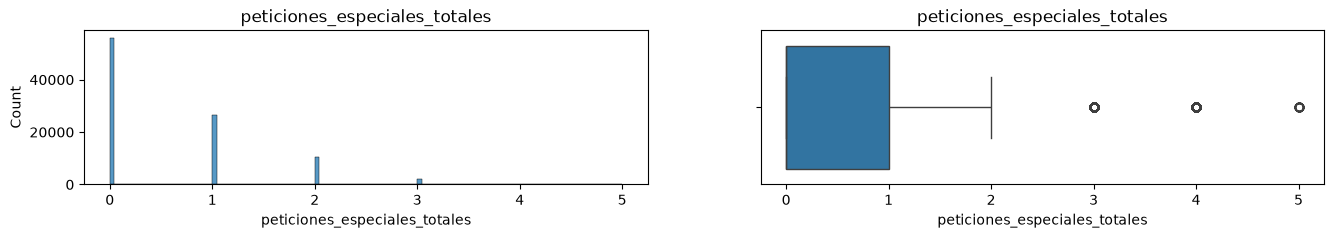

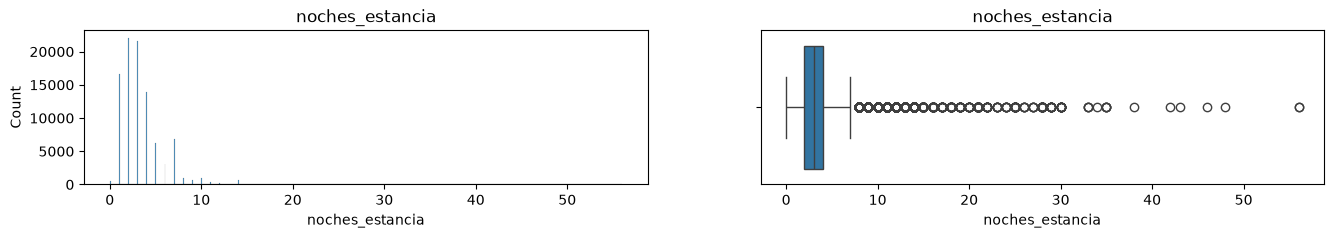

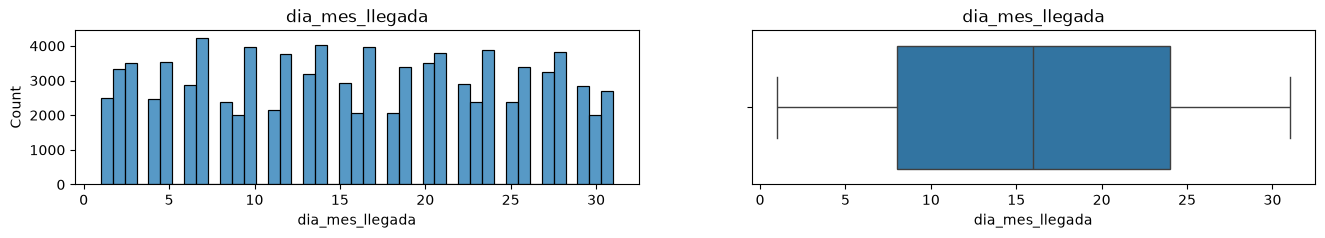

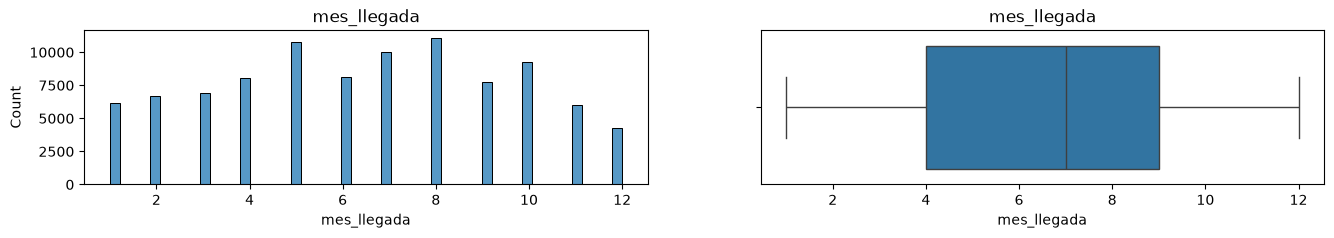

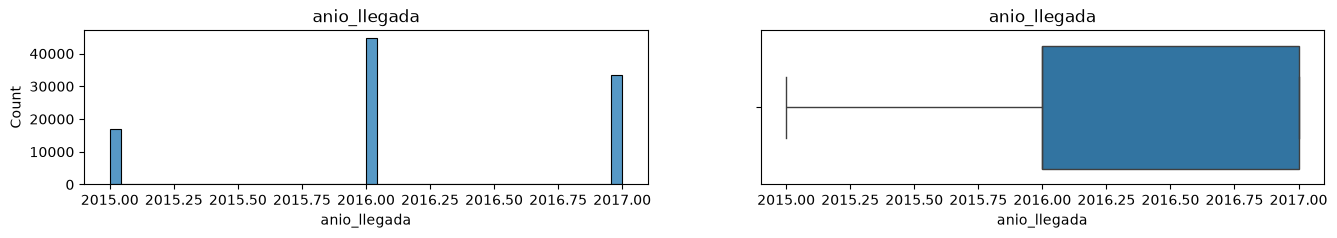

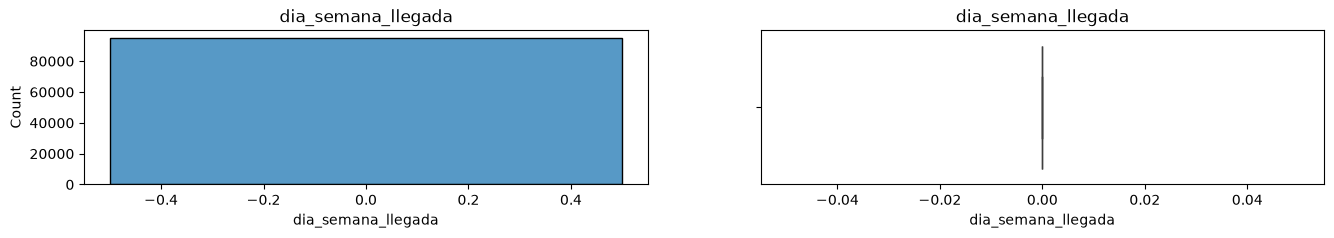

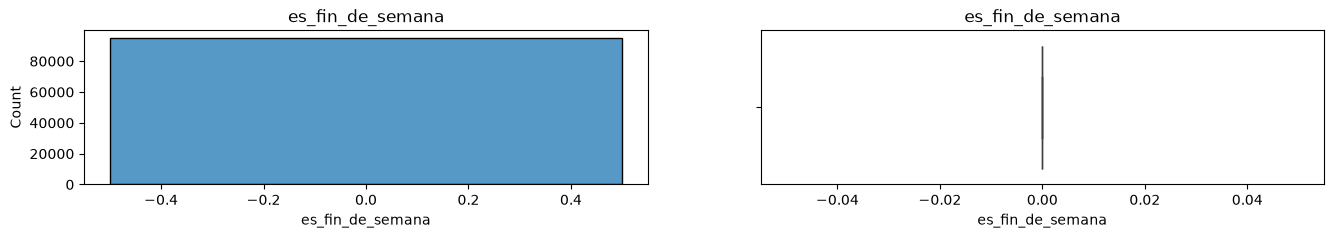

In [22]:
for col in num_cols:
   
    plt.figure(figsize=(16, 2))
    plt.subplot(1,2,1)
    plt.title(col)
    sns.histplot(X_train[col])
    plt.subplot(1,2,2)
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

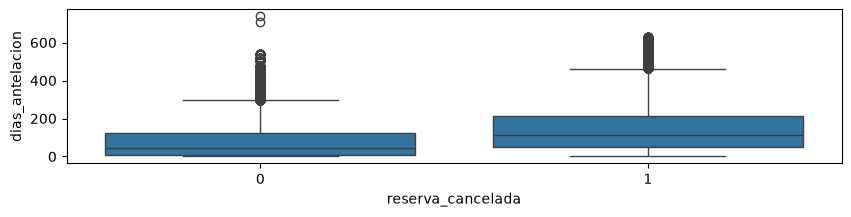

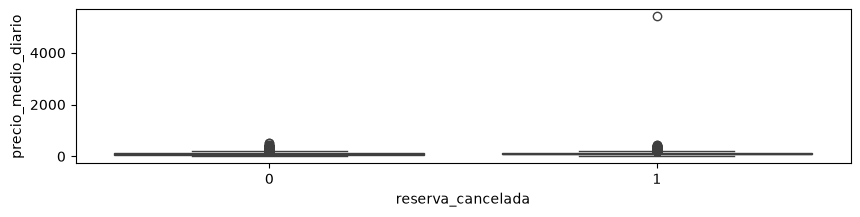

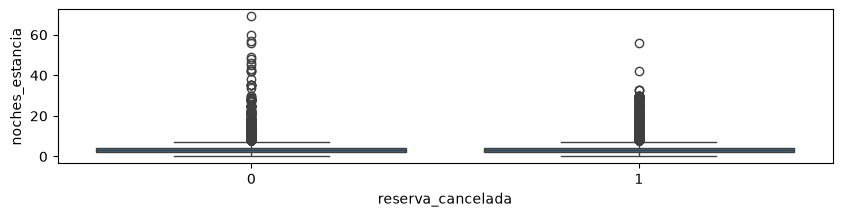

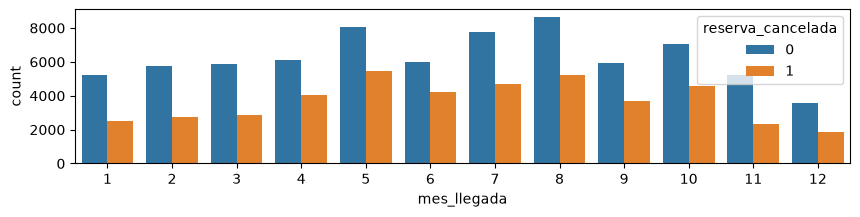

In [23]:
# Bivariate analysis

plt.figure(figsize=(10, 2))
sns.boxplot(x='reserva_cancelada', y='dias_antelacion', data=df1)
plt.show()

plt.figure(figsize=(10, 2))
sns.boxplot(x='reserva_cancelada', y='precio_medio_diario', data=df1)
plt.show()

plt.figure(figsize=(10, 2))
sns.boxplot(x='reserva_cancelada', y='noches_estancia', data=df1)
plt.show()

plt.figure(figsize=(10, 2))
sns.countplot(data=df1, x='mes_llegada', hue='reserva_cancelada')
plt.show()

<Figure size 1000x200 with 0 Axes>

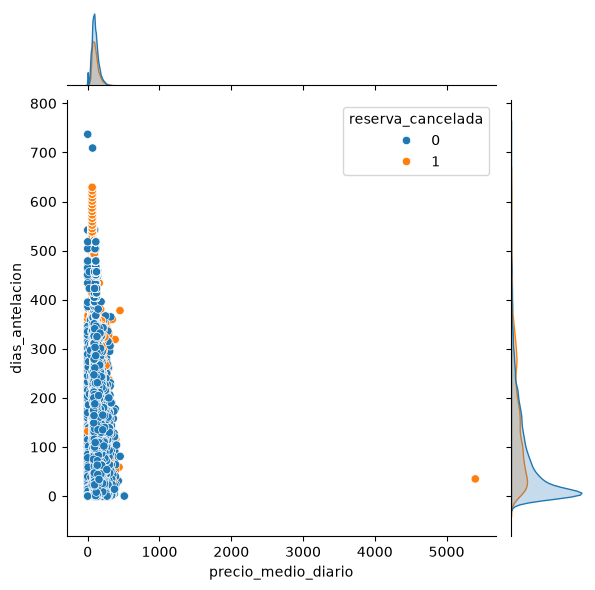

In [24]:
plt.figure(figsize=(10, 2))
sns.jointplot(data=df1, x='precio_medio_diario', y='dias_antelacion', hue='reserva_cancelada')
plt.show()

In [25]:
# The plot above shows there isn't a clear relationship between the average daily rate and the lead time with respect to booking cancellation.

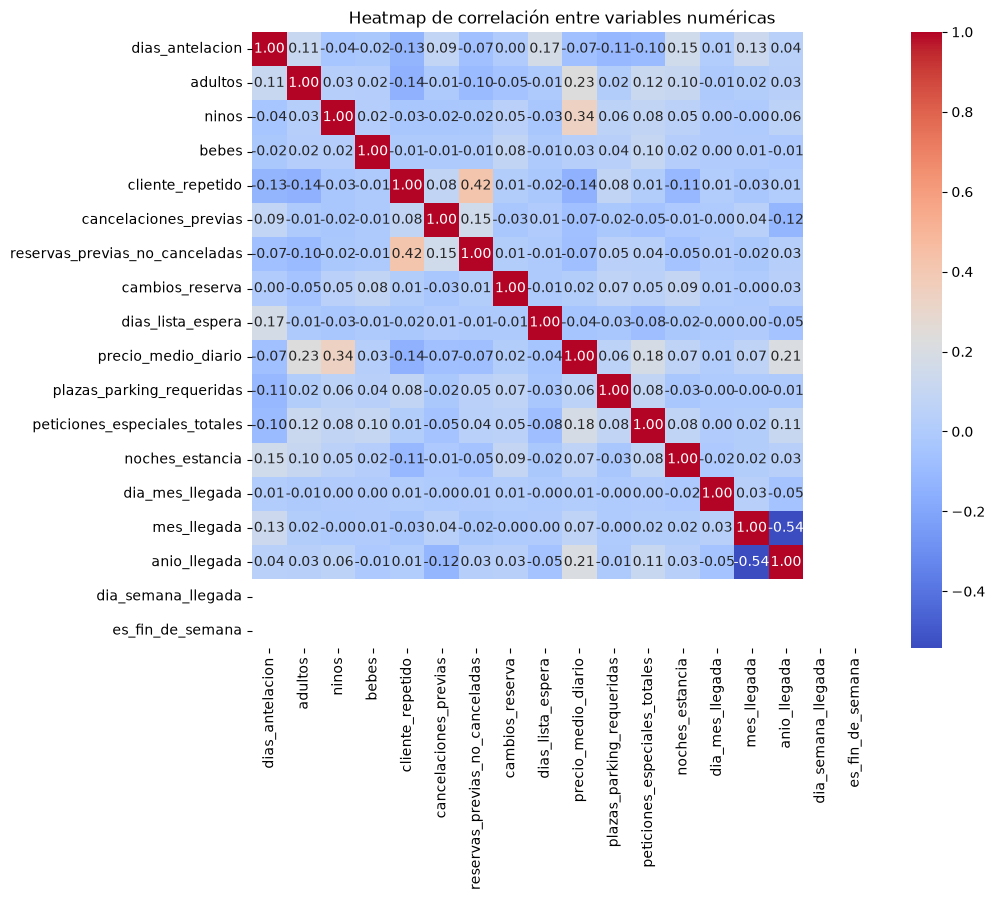

In [26]:
# Correlation heatmap between numeric variables
plt.figure(figsize=(10, 8))
correlation_matrix = X_train[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation heatmap between numeric variables')
plt.show()

In [27]:
df1['precio_medio_diario'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: precio_medio_diario, dtype: float64

In [28]:
df1[df1['precio_medio_diario']==(df1['precio_medio_diario'].max())]

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,noches_estancia,dia_mes_llegada,mes_llegada,anio_llegada,dia_semana_llegada,es_fin_de_semana
48515,1,35,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,0,Transient,5400.0,0,0,Canceled,1,28,3,2016,0,0


Feature transformations are applied in this section as needed (OneHotEncoder, LabelEncoder, PowerTransformer, KBinsDiscretizer, etc.), including any other _scikit-learn_ function or custom transformation.

<div class="alert alert-block alert-warning">
<b>Important:</b> Care is taken with these transformations, since the explanatory model and the predictive model don't necessarily benefit from the same ones. Only transformations useful for <b>both</b> models are applied here.
</div>

In [29]:
# There are a few binary variables.
# It's also worth noting that every dia_semana_llegada value falls on a Monday, so this variable carries no information and can be dropped.
X_train.drop(columns=['dia_semana_llegada'], inplace=True)
X_test.drop(columns=['dia_semana_llegada'], inplace=True)

In [30]:
# Group countries of origin into an "OTROS" (other) category for those with fewer than 100 occurrences in the training set.
frecuencia_pais = X_train['pais_origen'].value_counts()

# Keep the top 10 and assign the rest to "OTROS"
paises_frecuentes = frecuencia_pais.nlargest(10).index

X_train['pais_origen'] = X_train['pais_origen'].where(
    X_train['pais_origen'].isin(paises_frecuentes),
    'OTROS'
)

X_test['pais_origen'] = X_test['pais_origen'].where(
    X_test['pais_origen'].isin(paises_frecuentes),
    'OTROS'
)


In [31]:
# Filter out outliers in precio_medio_diario and dias_antelacion across the whole dataset
# Define the thresholds for precio_medio_diario
precio_max = X_train['precio_medio_diario'].quantile(0.95)
dias_antelacion_max = X_train['dias_antelacion'].quantile(0.95)

# This is done only on X_train to avoid leaking information from the test set.
X_train = X_train[(X_train['precio_medio_diario'] <= precio_max) & (X_train['dias_antelacion'] <= dias_antelacion_max)]

# Apply standard scaler to precio_medio_diario and a power transformer to dias_antelacion
pt = PowerTransformer(method='yeo-johnson', standardize=True)
scaler = StandardScaler()
X_train['precio_sc'] = scaler.fit_transform(X_train[['precio_medio_diario']])
X_test['precio_sc'] = scaler.transform(X_test[['precio_medio_diario']])

# Apply the power transformer to dias_antelacion
X_train['dias_antelacion_pt'] = pt.fit_transform(X_train[['dias_antelacion']])
X_test['dias_antelacion_pt'] = pt.transform(X_test[['dias_antelacion']])

# Drop the original precio_medio_diario and dias_antelacion columns to avoid multicollinearity
X_train.drop(columns=['precio_medio_diario', 'dias_antelacion'], inplace=True)
X_test.drop(columns=['precio_medio_diario', 'dias_antelacion'], inplace=True)


In [32]:
# Apply one-hot encoding to the categorical variables

X_train = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Align the columns of X_train and X_test so they match after one-hot encoding
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [33]:
constantes = X_train.columns[X_train.nunique() == 1]
print(f"Constant columns: {constantes.tolist()}")

Columnas constantes: ['es_fin_de_semana']


In [34]:
X_train.head()

,adultos,ninos,bebes,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,cambios_reserva,dias_lista_espera,plazas_parking_requeridas,peticiones_especiales_totales,noches_estancia,dia_mes_llegada,mes_llegada,anio_llegada,es_fin_de_semana,precio_sc,dias_antelacion_pt,regimen_alimenticio_FB,regimen_alimenticio_HB,regimen_alimenticio_SC,regimen_alimenticio_Undefined,pais_origen_BRA,pais_origen_DEU,pais_origen_ESP,pais_origen_FRA,pais_origen_GBR,pais_origen_IRL,pais_origen_ITA,pais_origen_NLD,pais_origen_OTROS,pais_origen_PRT,segmento_mercado_Complementary,segmento_mercado_Corporate,segmento_mercado_Direct,segmento_mercado_Groups,segmento_mercado_Offline TA/TO,segmento_mercado_Online TA,canal_distribucion_Direct,canal_distribucion_GDS,canal_distribucion_TA/TO,canal_distribucion_Undefined,tipo_habitacion_reservada_B,tipo_habitacion_reservada_C,tipo_habitacion_reservada_D,tipo_habitacion_reservada_E,tipo_habitacion_reservada_F,tipo_habitacion_reservada_G,tipo_habitacion_reservada_H,tipo_habitacion_reservada_L,tipo_habitacion_reservada_P,tipo_habitacion_asignada_B,tipo_habitacion_asignada_C,tipo_habitacion_asignada_D,tipo_habitacion_asignada_E,tipo_habitacion_asignada_F,tipo_habitacion_asignada_G,tipo_habitacion_asignada_H,tipo_habitacion_asignada_I,tipo_habitacion_asignada_K,tipo_habitacion_asignada_L,tipo_habitacion_asignada_P,tipo_deposito_Non Refund,tipo_deposito_Refundable,tipo_cliente_Group,tipo_cliente_Transient,tipo_cliente_Transient-Party
34563,2,0.0,0,0,0,0,0,0,0,0,4,20,3,2017,0,-1.708380,1.312571,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
117791,1,0.0,0,0,0,0,0,0,0,0,1,7,8,2017,0,1.137638,-1.808891,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
44311,2,0.0,0,0,0,0,0,0,0,0,4,5,10,2015,0,-0.884860,0.355827,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
22365,2,0.0,0,0,0,0,0,0,0,0,3,28,3,2016,0,-1.299732,-1.218633,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
82068,1,0.0,0,0,0,0,0,0,0,0,1,21,12,2015,0,-0.807072,-0.637167,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [35]:
# Drop constant columns
X_train.drop(columns=constantes, inplace=True)
X_test.drop(columns=constantes, inplace=True)

In [36]:
# Explanation of the new features / transformations performed
# The number of categories in pais_origen was reduced by grouping everything outside the top 10 most frequent countries of origin.
# A standard scaler was applied to precio_medio_diario and a power transformer to dias_antelacion to reduce the influence of extreme values, and the original variables were dropped to avoid multicollinearity.

In [37]:
X_train.shape

(85727, 65)

Finally, the feature plots are generated again to reflect the transformations applied above.

In [38]:
# cat_cols = ...
ord_cols = ...
# Exclude one-hot encoded columns from the numeric columns list
ohe_columns = [col for col in X_train.columns if X_train[col].nunique() == 2 and col not in cat_cols and col]
num_cols = [col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
            if col not in ohe_columns]

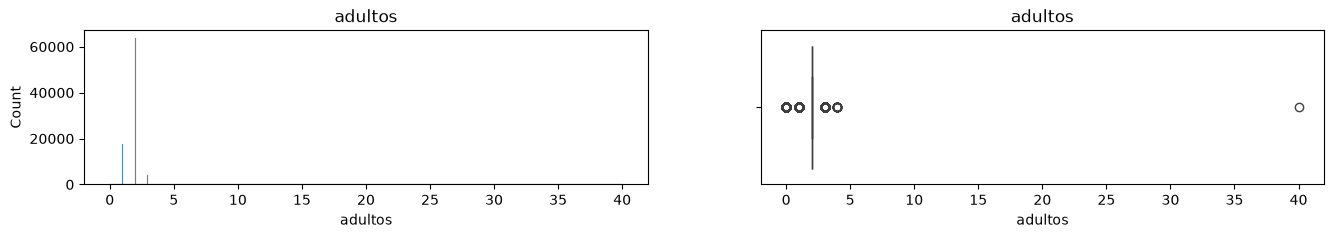

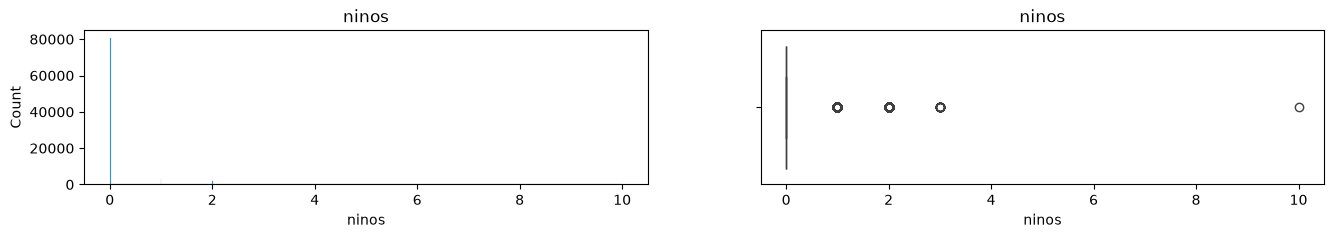

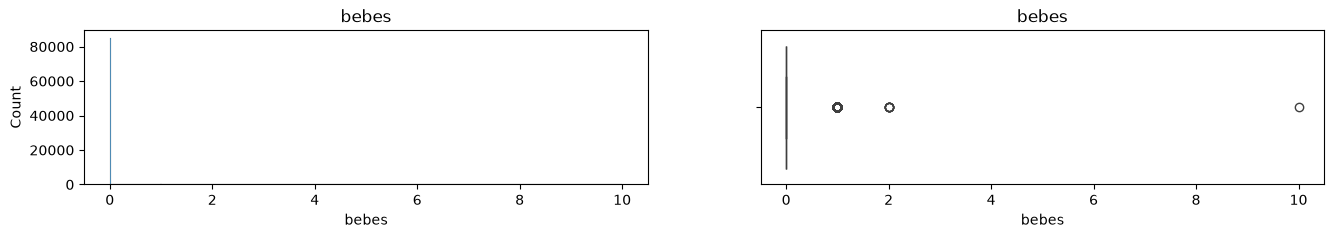

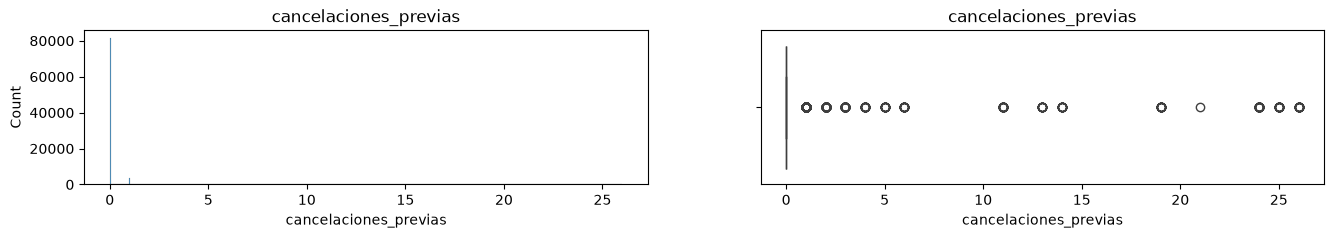

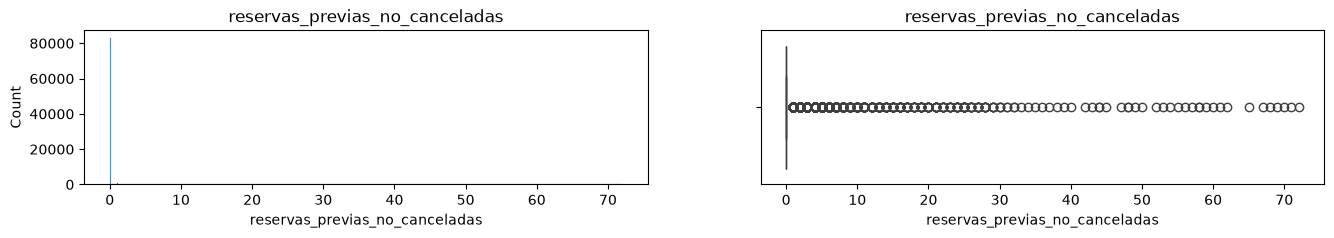

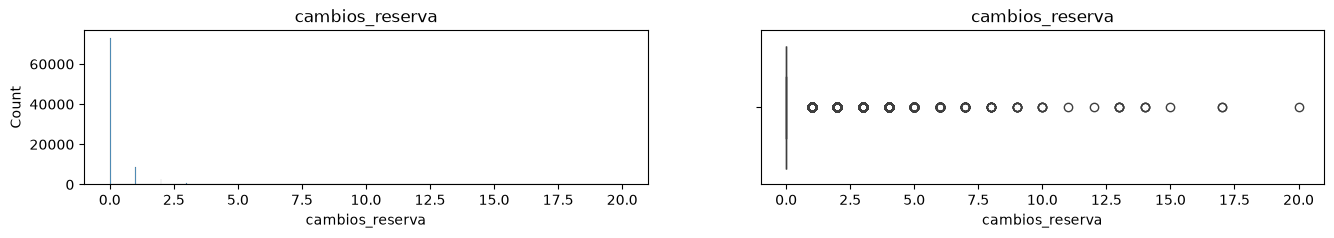

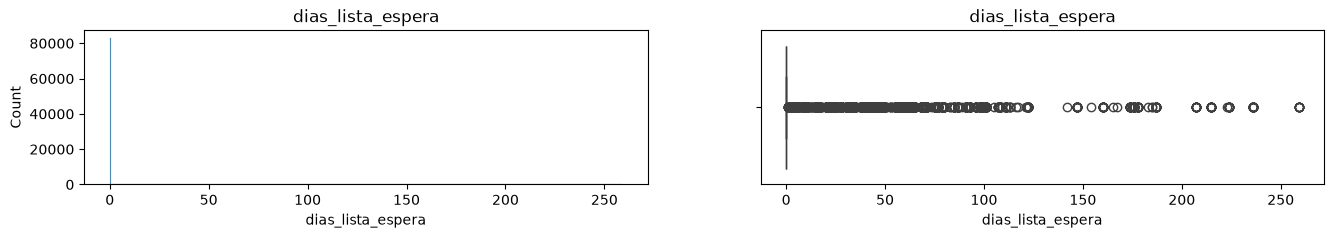

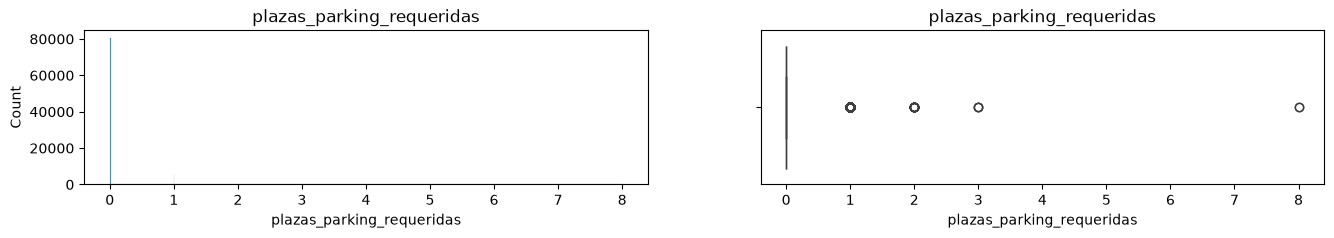

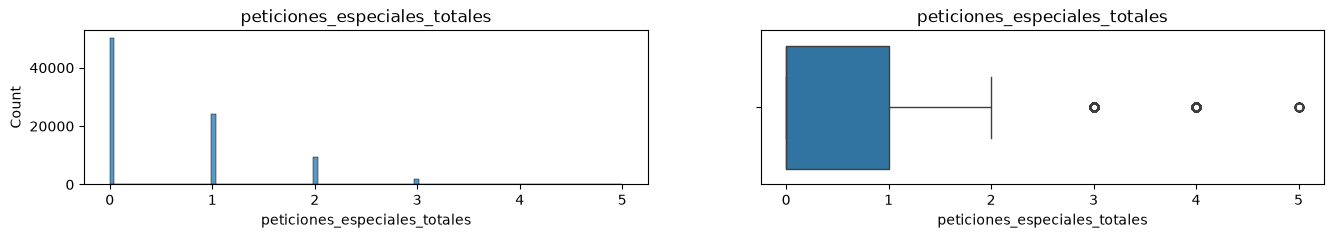

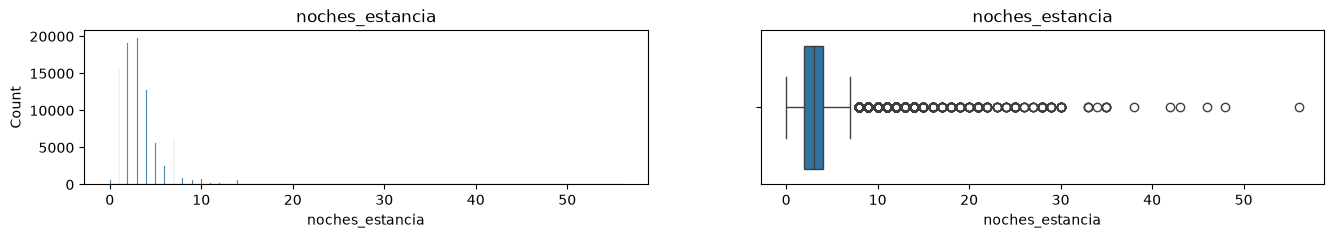

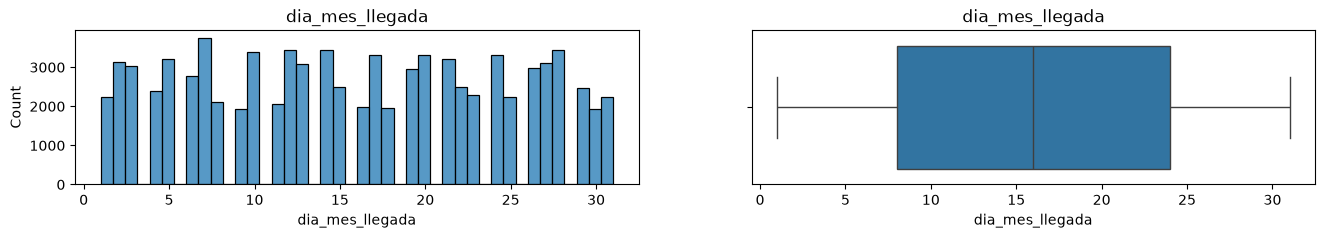

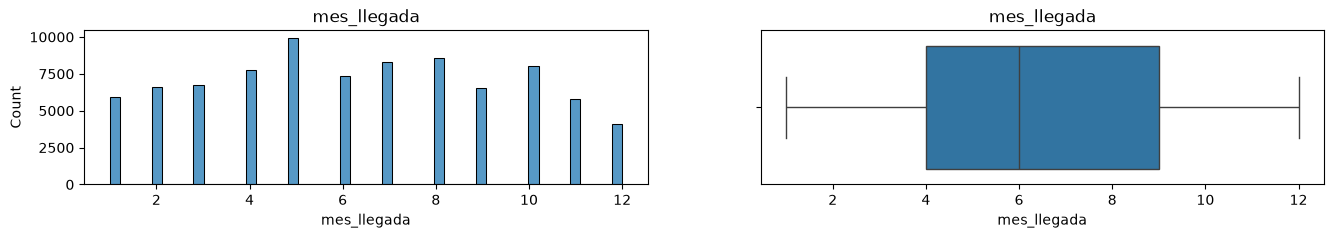

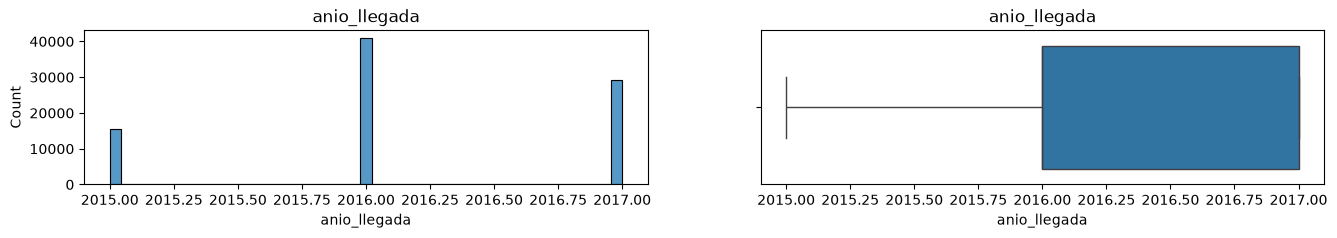

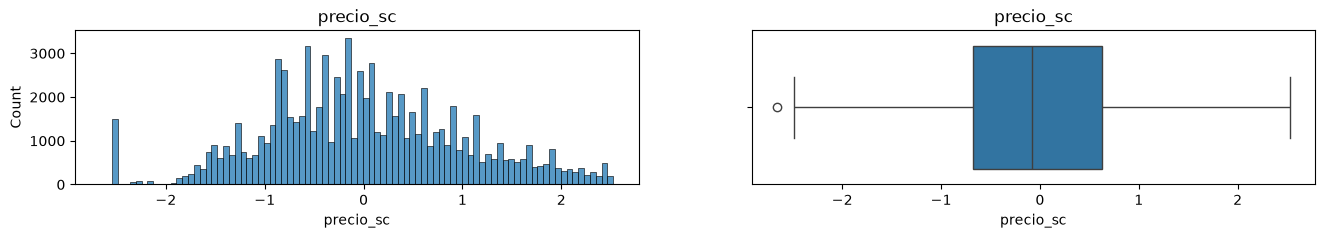

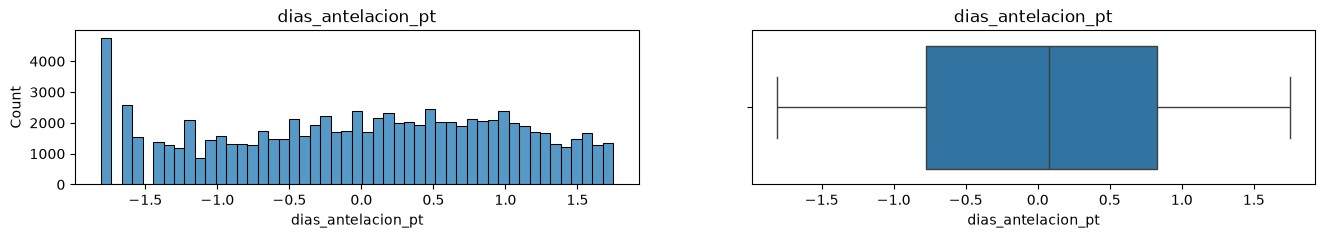

In [39]:
for col in num_cols:
    plt.figure(figsize=(16, 2))
    plt.subplot(1,2,1)
    plt.title(col)
    sns.histplot(X_train[col])
    plt.subplot(1,2,2)
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()


# Part 2: Explanatory Model

Given how large the sample is, an explanatory model can be built confidently on the training set alone, without touching the test set.

This section covers the full analysis, carried out exclusively with the _statsmodels_ library, needed to fit an explanatory logistic regression model. This involves dropping some features, modifying existing ones, creating new ones, handling outliers, plots, analysis, etc.

Every iteration and decision made along the way is reflected and commented on below.

In [40]:
# Check multicollinearity with VIF (Variance Inflation Factor)

vif = pd.DataFrame()

X_train_vif = X_train[num_cols].copy()

vif["Variable"] = X_train_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_train_vif.values, i)
    for i in range(X_train_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)


,Variable,VIF
12,anio_llegada,25.522496
0,adultos,16.381696
11,mes_llegada,5.054241
10,dia_mes_llegada,4.224879
9,noches_estancia,3.125901
8,peticiones_especiales_totales,1.642306
14,dias_antelacion_pt,1.207460
13,precio_sc,1.154978
5,cambios_reserva,1.146289
1,ninos,1.111262


In [41]:
X_train.drop(columns=['anio_llegada', 'adultos'], inplace=True)
X_test.drop(columns=['anio_llegada', 'adultos'], inplace=True)

vif = pd.DataFrame()

X_train_vif = X_train[[col for col in num_cols if col not in ['anio_llegada', 'adultos']]].copy()

vif["Variable"] = X_train_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_train_vif.values, i)
    for i in range(X_train_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)


,Variable,VIF
10,mes_llegada,3.241880
9,dia_mes_llegada,3.014913
8,noches_estancia,2.539490
7,peticiones_especiales_totales,1.564578
12,dias_antelacion_pt,1.143647
4,cambios_reserva,1.136917
0,ninos,1.105177
6,plazas_parking_requeridas,1.091920
11,precio_sc,1.085535
3,reservas_previas_no_canceladas,1.058171


In [42]:
# Detect OHE columns with separation (a single class within some group)
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]

for col in binary_cols:
    ct = pd.crosstab(X_train[col], y_train.loc[X_train.index])
    if (ct == 0).any().any():
        print(f"Possible separation: {col}")

Posible separación: tipo_habitacion_reservada_P
Posible separación: tipo_habitacion_asignada_L
Posible separación: tipo_habitacion_asignada_P


In [43]:
# Drop all the OHE columns related to tipo_habitacion_reservada and tipo_habitacion_asignada,
# since they cause perfect separation with the target variable and add no additional information to the model.
# What does perfect separation mean?
# It's when a predictor variable can perfectly predict the target variable, which can lead to overfitting and a model that doesn't generalize well to new data.
# In code, this shows up as a "LinAlgError: Singular matrix" error while fitting the model.

cols_to_drop = [col for col in X_train.columns if col.startswith('tipo_habitacion_reservada_') or col.startswith('tipo_habitacion_asignada_')]
X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

y_train = y_train.loc[X_train.index]

Reference model — the final model used going forward is fit below.

In [44]:
X_train_explained_model = X_train.copy()[[col for col in num_cols if col not in ['anio_llegada', 'adultos', 'plazas_parking_requeridas']]]

X_train_sm = sm.add_constant(X_train_explained_model.astype(float))

y = y_train.loc[X_train_sm.index]

modelo = sm.Logit(y, X_train_sm)

resultado = modelo.fit(maxiter=500)

print(resultado.summary())


Optimization terminated successfully.
         Current function value: 0.535776
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                85727
Model:                          Logit   Df Residuals:                    85714
Method:                           MLE   Df Model:                           12
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                  0.1754
Time:                        18:49:06   Log-Likelihood:                -45930.
converged:                       True   LL-Null:                       -55701.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.0923      0.027      3.472     

In [45]:
conf = resultado.conf_int()
conf.columns = ['IC_inf','IC_sup']

df_results = pd.DataFrame({
    "Coef":resultado.params,
    "OR" : np.exp(resultado.params),
    "IC_inf": np.exp(conf['IC_inf']),
    "IC_sup": np.exp(conf['IC_sup']),
    "p_value": resultado.pvalues
})

df_results.drop('const').round(6)

,Coef,OR,IC_inf,IC_sup,p_value
ninos,0.055033,1.056576,1.008152,1.107325,0.021497
bebes,0.118736,1.126072,0.926345,1.368862,0.233288
cancelaciones_previas,2.737754,15.452244,13.712724,17.412430,0.000000
reservas_previas_no_canceladas,-0.572655,0.564026,0.534975,0.594654,0.000000
cambios_reserva,-0.697646,0.497755,0.479551,0.516651,0.000000
dias_lista_espera,-0.001660,0.998341,0.997324,0.999360,0.001422
peticiones_especiales_totales,-0.703340,0.494929,0.483407,0.506726,0.000000
noches_estancia,-0.022174,0.978070,0.971634,0.984548,0.000000
dia_mes_llegada,-0.003637,0.996369,0.994592,0.998150,0.000065
mes_llegada,-0.039066,0.961687,0.956654,0.966747,0.000000


In [46]:
# Relationship with the target variable
print(pd.crosstab(X_train['plazas_parking_requeridas'], y_train))

reserva_cancelada              0      1
plazas_parking_requeridas              
0                          50280  30328
1                           5097      0
2                             17      0
3                              3      0
8                              2      0


Summary of the conclusions from this analysis:

In [47]:
# Conclusions
# - Conclusion 1: The OR associated with cancelaciones_previas indicates that, holding all other variables constant, each prior cancellation multiplies the odds of cancelling the current booking by roughly 15.4.
# - Conclusion 2: The OR below 1 associated with reservas_previas_no_canceladas indicates that a higher number of successfully completed previous bookings reduces the odds of cancelling the current booking, suggesting that customers with a positive history are more reliable.
# - Conclusion 3: The negative coefficients of cambios_reserva and peticiones_especiales_totales suggest that customers who have made changes to their booking are less likely to cancel, which could indicate that these customers are more committed to their booking.
# - Conclusion 4: The transformed dias_antelacion variable has a positive effect on the odds of cancellation, suggesting that, in general, bookings made further in advance tend to be more prone to cancellation.
# - Conclusion 5: The standardized precio_sc variable shows a positive association with the odds of cancellation, suggesting that, in general, higher-priced bookings tend to be more prone to cancellation.

# Part 3: Predictive Model

This section builds a predictive model trained on the training set, using exclusively the _sklearn_ library to fit a predictive logistic regression model. This involves dropping some features, modifying existing ones, creating new ones, handling outliers, plots, analysis, etc.

In [48]:
X_train.head()


,ninos,bebes,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,cambios_reserva,dias_lista_espera,plazas_parking_requeridas,peticiones_especiales_totales,noches_estancia,dia_mes_llegada,mes_llegada,precio_sc,dias_antelacion_pt,regimen_alimenticio_FB,regimen_alimenticio_HB,regimen_alimenticio_SC,regimen_alimenticio_Undefined,pais_origen_BRA,pais_origen_DEU,pais_origen_ESP,pais_origen_FRA,pais_origen_GBR,pais_origen_IRL,pais_origen_ITA,pais_origen_NLD,pais_origen_OTROS,pais_origen_PRT,segmento_mercado_Complementary,segmento_mercado_Corporate,segmento_mercado_Direct,segmento_mercado_Groups,segmento_mercado_Offline TA/TO,segmento_mercado_Online TA,canal_distribucion_Direct,canal_distribucion_GDS,canal_distribucion_TA/TO,canal_distribucion_Undefined,tipo_deposito_Non Refund,tipo_deposito_Refundable,tipo_cliente_Group,tipo_cliente_Transient,tipo_cliente_Transient-Party
34563,0.0,0,0,0,0,0,0,0,0,4,20,3,-1.708380,1.312571,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1
117791,0.0,0,0,0,0,0,0,0,0,1,7,8,1.137638,-1.808891,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
44311,0.0,0,0,0,0,0,0,0,0,4,5,10,-0.884860,0.355827,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0
22365,0.0,0,0,0,0,0,0,0,0,3,28,3,-1.299732,-1.218633,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0
82068,0.0,0,0,0,0,0,0,0,0,1,21,12,-0.807072,-0.637167,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


In [49]:
modelo = LogisticRegression(
    max_iter=500,
    random_state=seed,
    l1_ratio=0.3,
    solver='liblinear',
    penalty='l1'
)

modelo.fit(X_train, y_train)

C:\Users\dgarc\anaconda3\envs\data_mining\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\dgarc\anaconda3\envs\data_mining\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\dgarc\anaconda3\envs\data_mining\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.3. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.3
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",99
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver ch

In [50]:
y_pred = modelo.predict(X_test)

y_prob = modelo.predict_proba(X_test)[:,1]

Finally, the test set is used to evaluate the model's performance, measuring accuracy **exclusively on the test set**. The probability threshold of the logistic regression is also explored for potential improvement.

In [51]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8142676767676768
Precision: 0.8033530300948193
Recall   : 0.6622111463525148
F1 Score : 0.7259857187208941
ROC AUC  : 0.891782624805932
